# Training loss + coverage scaling diagnostics (`pk+pgm` vs `pk+bispec`)

Compare **noiseless** `best-rand30` runs: `pk+pgm` (sampling OK on coverage) vs `pk+bispec` with `_kb0.25` (slow coverage sampling).

1. Plot **NPE training / validation loss** from saved `inference.p` (W&B best-run summary as a cross-check).
2. Load **training** and **coverage** summaries, apply the **same** `scaler_y_*.p` as inference, and quantify **out-of-training-range** scaled values (`bispec` uses `minmax`; `pk` / `pgm` use log-based scalers — see `utils_inference.statistics_scaler_funcs`).

No `chdir`. `data_loader` resolves **params** and **k-bin masks** under `paths.PROJECT_ROOT / "data" / …` (cwd-independent).

**Long runtimes:** each `load_data` walk does one `np.load` per (cosmology, bias row) per statistic. Nested train LH is ~10k cosmologies × ~32 bias rows ≈ **3.2×10⁵ loads per statistic** (bispec is especially slow on NFS). Tunables `SCALING_N_COSMO_MAX_TRAIN` / `SCALING_N_COSMO_MAX_COV` subsample cosmologies; use `None` for full libraries (slow).

**Last sections:** `pk+bispec` baseline vs `_best-rand30` vs 2nd-by-val-loss—loss curves, hyperparameters, scaler bounds; then **sweep rank by direct-posterior ESS proxy** (ArviZ on neural posterior draws; sbi `sample_with="direct"`) + same coverage timing.


In [1]:
import sys
import pickle
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    _cwd = Path.cwd().resolve()
    if (_cwd / "code").is_dir():
        REPO_ROOT = _cwd
    elif _cwd.name == "notebooks" and (_cwd.parent / "code").is_dir():
        REPO_ROOT = _cwd.parent
    elif _cwd.name == "code":
        REPO_ROOT = _cwd.parent
    else:
        REPO_ROOT = _cwd

CODE = REPO_ROOT / "code"
sys.path.insert(0, str(CODE))

import numpy as np
import matplotlib.pyplot as plt

import paths
import data_loader
import utils_inference
from generate_config_inference import BX_SWEEP, N_TRAIN_SWEEP, resolve_train_tag_bundle
import yaml
import wandb
from sbi_model import _WANDB_SWEEP_PARAMETER_KEYS, wandb_sweep_best_run

WANDB_PROJECT = "muchisimocks-sbi"
%matplotlib inline

2026-04-10 00:59:40.404144: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 00:59:40.637320: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 00:59:40.637367: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 00:59:40.659926: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-10 00:59:40.733223: I tensorflow/core/platform/cpu_feature_guar

In [2]:
data_mode = "muchisimocks"
bx = 32
n_train = 10_000
reparameterize = True
tag_sweep = "-rand30"

# Subsample cosmologies in ``load_data`` (fixed seed inside ``load_data_muchisimocks``).
# Full train: ~10k cosmologies × ~32 nested bias rows → ~3.2e5 ``np.load`` per statistic (very slow).
SCALING_N_COSMO_MAX_TRAIN = 120  # None => full LH + exact SBI first-n_train cosmo slice
SCALING_N_COSMO_MAX_COV = 400   # None => all coverage cosmologies

t_train = resolve_train_tag_bundle("_p5_n10000", "noiseless")
TAG_PARAMS = t_train["tag_params"]
TAG_BIASPARAMS = t_train["tag_biasparams"]
TAG_NOISE = t_train["tag_noise"]

TAG_PARAMS_COV = "_coverage_p5_n1000"
TAG_BIASPARAMS_COV = "_biascoverage_p4_n1000"

CASES = {
    "pk+pgm (good)": {
        "statistics": ["pk", "pgm"],
        "tags_mask": ["", ""],
    },
    "pk+bispec (slow coverage)": {
        "statistics": ["pk", "bispec"],
        "tags_mask": ["", "_kb0.25"],
    },
}


def build_tag_inf(statistics, tags_mask):
    tag_masks = "".join(tags_mask)
    tag_stats = f'_{"_".join(statistics)}'
    tag_paramsall = TAG_PARAMS + TAG_BIASPARAMS + (TAG_NOISE or "")
    mid = f"_{data_mode}{tag_stats}{tag_masks}{tag_paramsall}"
    rp = "_rp" if reparameterize else ""
    return f"{mid}{rp}_bx{bx}_ntrain{n_train}_best{tag_sweep}"


def build_sweep_name(statistics, tags_mask):
    tag_masks = "".join(tags_mask)
    tag_stats = f'_{"_".join(statistics)}'
    tag_paramsall = TAG_PARAMS + TAG_BIASPARAMS + (TAG_NOISE or "")
    mid = f"_{data_mode}{tag_stats}{tag_masks}{tag_paramsall}"
    rp = "_rp" if reparameterize else ""
    return f"{mid}{rp}_bx{BX_SWEEP}_ntrain{N_TRAIN_SWEEP}_sweep{tag_sweep}"


def dir_sbi_for(tag_inf_suffix: str) -> Path:
    return paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_inf_suffix}"

In [3]:
def training_idx_subset(y0, idxs_params, random_ints_cosmo, n_train_used):
    """Match ``run_inference.train_likefree_inference`` indexing."""
    idxs_cosmo_subset = random_ints_cosmo[: int(n_train_used)]
    idxs_all = np.arange(len(y0))
    idxs_train = idxs_all[np.isin(idxs_params[:, 0], idxs_cosmo_subset)]
    return idxs_train


def load_y_train_and_coverage(statistics, tags_mask):
    (
        k_tr,
        y_tr,
        y_err_tr,
        idxs_params,
        params_df,
        param_dict_fixed,
        biasparams_df,
        biasparams_dict_fixed,
        random_ints_cosmo,
        random_ints_bias,
    ) = data_loader.load_data(
        data_mode,
        statistics,
        TAG_PARAMS,
        TAG_BIASPARAMS,
        tag_noise=TAG_NOISE,
        tags_mask=tags_mask,
        bx=bx,
        n_cosmo_max=SCALING_N_COSMO_MAX_TRAIN,
    )
    if random_ints_cosmo is None:
        raise RuntimeError("random_ints_cosmo is None; need randints for training tag")
    if SCALING_N_COSMO_MAX_TRAIN is None:
        idxs_train = training_idx_subset(y_tr[0], idxs_params, random_ints_cosmo, n_train)
        y_train = [y_tr[i][idxs_train].copy() for i in range(len(statistics))]
    else:
        print(
            f"[scaling diag] train: {len(y_tr[0]):,} rows from n_cosmo_max={SCALING_N_COSMO_MAX_TRAIN} "
            f"(approximate training distribution; not the exact SBI first-{n_train} cosmo row slice)."
        )
        y_train = [y_tr[i].copy() for i in range(len(statistics))]

    k_cv, y_cv, y_err_cv, *_ = data_loader.load_data(
        data_mode,
        statistics,
        TAG_PARAMS_COV,
        TAG_BIASPARAMS_COV,
        tag_noise=None,
        tags_mask=tags_mask,
        bx=None,
        n_cosmo_max=SCALING_N_COSMO_MAX_COV,
    )
    if SCALING_N_COSMO_MAX_COV is not None:
        print(f"[scaling diag] coverage: {len(y_cv[0]):,} rows (n_cosmo_max={SCALING_N_COSMO_MAX_COV})")
    return y_train, [y_cv[i].copy() for i in range(len(statistics))]


def load_scalers(dir_sbi: Path, statistics):
    out = []
    for s in statistics:
        fn = dir_sbi / f"scaler_y_{s}.p"
        if not fn.is_file():
            raise FileNotFoundError(fn)
        with open(fn, "rb") as f:
            out.append(pickle.load(f))
    return out


def load_losses_from_inference_p(dir_sbi: Path):
    fn = dir_sbi / "inference.p"
    if not fn.is_file():
        return None
    with open(fn, "rb") as f:
        inf = pickle.load(f)
    summ = getattr(inf, "_summary", None)
    if not summ:
        return None
    return {
        "training_loss": np.asarray(summ.get("training_loss", []), dtype=float),
        "validation_loss": np.asarray(summ.get("validation_loss", []), dtype=float),
    }


def wandb_best_summary(sweep_name: str):
    api = wandb.Api()
    sweeps = api.project(WANDB_PROJECT).sweeps()
    sw = next((s for s in sweeps if s.name == sweep_name), None)
    if sw is None:
        return None
    best = wandb_sweep_best_run(sw, minimize="best_validation_loss")
    run = api.run(f"{api.default_entity}/{WANDB_PROJECT}/{best.id}")
    sm = dict(run.summary)
    return {"run_id": best.id, "sweep_id": sw.id, "summary": sm}


def ood_minmax_scaled(y_scaled: np.ndarray, lo=0.0, hi=1.0):
    """Fraction of rows with any feature outside [lo, hi] (typical for train-fit minmax / log_minmax)."""
    bad = (y_scaled < lo) | (y_scaled > hi)
    return bad.any(axis=1).mean(), bad.mean()


def print_scaling_report(label, statistics, scalers, y_train, y_cov):
    print("=" * 72)
    print(label)
    for i, s in enumerate(statistics):
        sc = scalers[i]
        yt = sc.scale(y_train[i])
        yc = sc.scale(y_cov[i])
        row_frac, elem_frac = ood_minmax_scaled(yc)
        print(f"  [{s}] scaler={sc.func!r}  train shape={y_train[i].shape}  cov shape={y_cov[i].shape}")
        print(
            f"       scaled train: min {np.nanmin(yt):.4g} max {np.nanmax(yt):.4g} | "
            f"cov min {np.nanmin(yc):.4g} max {np.nanmax(yc):.4g}"
        )
        print(
            f"       cov outside [0,1]: {row_frac*100:.2f}% rows (any bin), "
            f"{elem_frac*100:.2f}% of all (row,bin)"
        )

wandb: Sorting runs by +summary_metrics.best_validation_loss
wandb: Sorting runs by +summary_metrics.best_validation_loss


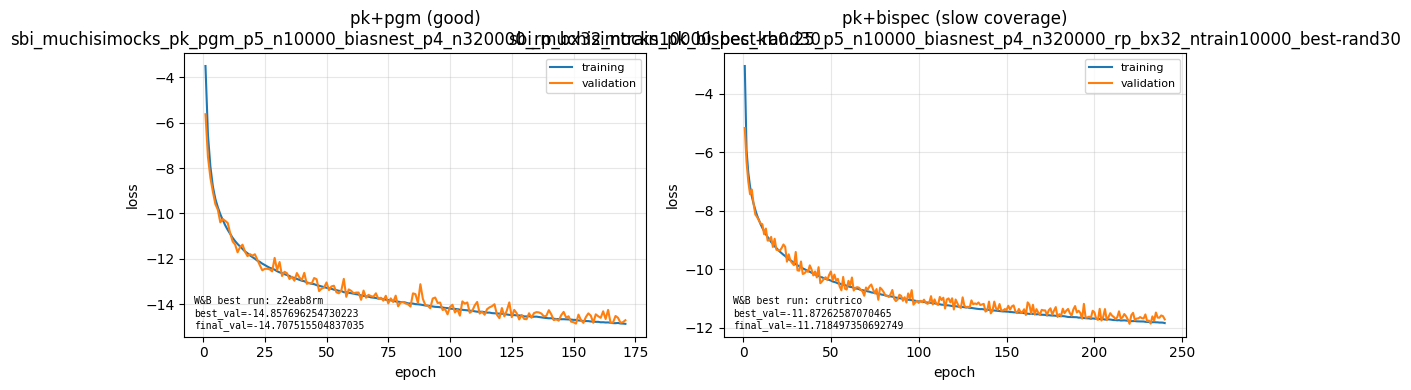

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=False)

for ax, (label, spec) in zip(axes, CASES.items()):
    statistics = spec["statistics"]
    tags_mask = spec["tags_mask"]
    tag_inf = build_tag_inf(statistics, tags_mask)
    d = dir_sbi_for(tag_inf)
    losses = load_losses_from_inference_p(d)
    sweep_name = build_sweep_name(statistics, tags_mask)
    wb = wandb_best_summary(sweep_name)

    ax.set_title(label + f"\n{d.name}")
    if losses is None or losses["training_loss"].size == 0:
        ax.text(0.5, 0.5, f"No loss curves in\n{d / 'inference.p'}", ha="center", va="center")
    else:
        tr = losses["training_loss"]
        va = losses["validation_loss"]
        epochs = np.arange(1, len(tr) + 1)
        ax.plot(epochs, tr, label="training", color="C0")
        if va.size:
            ax.plot(epochs[: len(va)], va, label="validation", color="C1")
        ax.legend(fontsize=8)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.grid(alpha=0.3)

    if wb:
        sm = wb["summary"]
        ax.text(
            0.02,
            0.02,
            f"W&B best run: {wb['run_id']}\n"
            f"best_val={sm.get('best_validation_loss')}\n"
            f"final_val={sm.get('final_validation_loss')}",
            transform=ax.transAxes,
            fontsize=7,
            va="bottom",
            fontfamily="monospace",
        )

plt.tight_layout()
plt.show()

In [5]:
### TAKES FOREVER

# for label, spec in CASES.items():
#     statistics = spec["statistics"]
#     tags_mask = spec["tags_mask"]
#     tag_inf = build_tag_inf(statistics, tags_mask)
#     d = dir_sbi_for(tag_inf)
#     y_train, y_cov = load_y_train_and_coverage(statistics, tags_mask)
#     scalers = load_scalers(d, statistics)
#     print(f"\nscaler funcs (code): {[utils_inference.statistics_scaler_funcs[s] for s in statistics]}")
#     print_scaling_report(label, statistics, scalers, y_train, y_cov)

In [6]:
# def plot_scaled_hist_comparison(statistics, tags_mask, label):
#     tag_inf = build_tag_inf(statistics, tags_mask)
#     d = dir_sbi_for(tag_inf)
#     y_train, y_cov = load_y_train_and_coverage(statistics, tags_mask)
#     scalers = load_scalers(d, statistics)

#     n_stats = len(statistics)
#     fig, axes = plt.subplots(n_stats, 3, figsize=(12, 2.8 * n_stats), squeeze=False)
#     fig.suptitle(f"{label} — scaled marginals at bin j (train filled / cov step); shading typical [0,1] range")

#     for row, s in enumerate(statistics):
#         sc = scalers[row]
#         yt = sc.scale(y_train[row])
#         yc = sc.scale(y_cov[row])
#         P = yt.shape[1]
#         bins_pick = sorted({0, P // 2, P - 1})
#         for col, j in enumerate(bins_pick):
#             ax = axes[row, col]
#             ax.hist(yt[:, j], bins=40, alpha=0.45, density=True, color="C0", label="train")
#             ax.hist(yc[:, j], bins=40, alpha=0.9, density=True, histtype="step", color="C1", linewidth=1.4, label="coverage")
#             ax.axvspan(0, 1, color="k", alpha=0.06, zorder=0)
#             ax.set_title(f"{s} ({sc.func})  bin {j}")
#             ax.set_xlabel("scaled")
#             ax.legend(fontsize=7)
#             ax.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.show()


# for label, spec in CASES.items():
#     plot_scaled_hist_comparison(spec["statistics"], spec["tags_mask"], label)

## `pk+bispec` baseline vs `best-rand30` vs 2nd-best sweep (coverage sampling)

Compare **training** loss curves, **`config.pkl` hyperparameters**, and **scaler** `x_train_min` / `x_train_max` for:

- **Baseline** (`…_ntrain10000` only): coverage posterior sampling OK.
- **`_best-rand30`**: sweep best hyperparameters; coverage sampling problematic.
- **2nd-best** (`sbi<sweep-rand30>/<run_id>/`): next-best finished sweep run by W&B `best_validation_loss`.

Directories are under `paths.DIR_RESULTS / "results_sbi" / …` (same tree as `/scratch/kstoreyf/muchisimocks/results/…`).

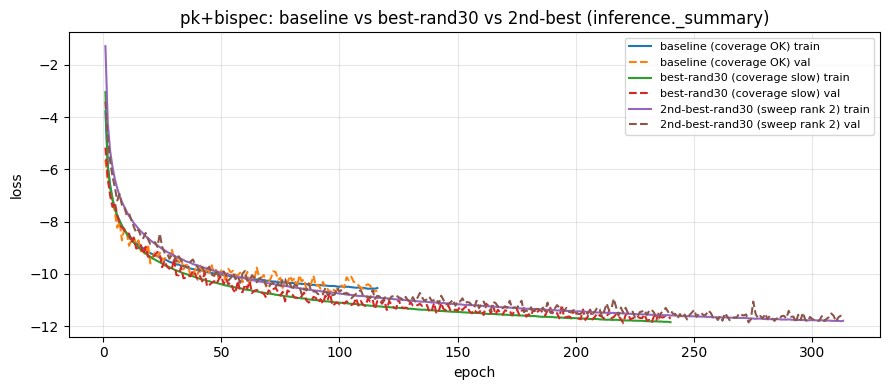

Hyperparameters
baseline (coverage OK)
  dir: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000
  training yaml: /home/kstoreyf/muchisimocks/configs/configs_train/config_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000.yaml
  run_mode (yaml): single
  hyperparameters: SBIModel.run(run_mode='single') defaults (code/sbi_model.py)
    learning_rate: 0.001
    hidden_features: 128
    training_batch_size: 64
    num_transforms: 5
    model_type: maf
    max_epochs: 2000
    validation_fraction: 0.1
  note: config.pkl is empty dict — fit_model saves vars(wandb.config); often no public keys, so use yaml / W&B above.



wandb: Sorting runs by +summary_metrics.best_validation_loss


best-rand30 — W&B sweep best (same pattern as 2026-04-05_inference_best-rand30)
  dir: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30
  sweep_name: _muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30
  sweep_id=2etgqv2r  best_run=crutrico
  runtime=7h 31m 55s
  summary_metrics.best_validation_loss=-11.87262587070465
  summary_metrics.final_validation_loss=-11.718497350692749
  learning_rate: 0.0001
  hidden_features: 256
  training_batch_size: 32
  num_transforms: 4
  max_epochs: 2000
  validation_fraction: 0.1
  model_type: maf

2nd-best-rand30 — W&B sweep rank 2
  dir: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30/3qjtopvp
  sweep_name: _muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30
  run_2nd=3qjto

In [7]:
TAG_INF_PKBI_SHARED = (
    "_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000"
)
DIR_PKBI_BASELINE = paths.DIR_RESULTS / "results_sbi" / f"sbi{TAG_INF_PKBI_SHARED}"
DIR_PKBI_BEST_RAND30 = paths.DIR_RESULTS / "results_sbi" / f"sbi{TAG_INF_PKBI_SHARED}_best-rand30"

SWEEP_NAME_PKBI = build_sweep_name(["pk", "bispec"], ["", "_kb0.25"])


def _sweeps_by_name(project):
    from collections import defaultdict

    g = defaultdict(list)
    for s in project.sweeps():
        g[s.name].append(s)
    out = {}
    for name, m in g.items():
        out[name] = m[0] if len(m) == 1 else max(m, key=lambda sw: len(list(sw.runs)))
    return out


def wandb_ranked_finished_runs(sw, *, minimize="best_validation_loss"):
    """Finished sweep runs with a logged ``minimize`` summary, best first."""
    rows = []
    for r in sw.runs:
        st = str(getattr(r, "state", "")).lower()
        if st not in {"finished", "completed"}:
            continue
        sm = dict(r.summary)
        v = sm.get(minimize)
        if v is None:
            continue
        rows.append((float(v), r))
    rows.sort(key=lambda x: x[0])
    return [r for _, r in rows]


TAG_SBI_PKBI_BASELINE = TAG_INF_PKBI_SHARED
TAG_SBI_PKBI_BEST = f"{TAG_INF_PKBI_SHARED}_best-rand30"
TAG_SBI_PKBI_2ND = None
DIR_PKBI_2ND_SWEEP = None
RUN_2ND_ID = None

_api_wb = wandb.Api()
_by_name_pkbi = _sweeps_by_name(_api_wb.project(WANDB_PROJECT))
_sw_pkbi = _by_name_pkbi.get(SWEEP_NAME_PKBI)
if _sw_pkbi is not None:
    _ranked_pkbi = wandb_ranked_finished_runs(_sw_pkbi)
    if len(_ranked_pkbi) >= 2:
        RUN_2ND_ID = _ranked_pkbi[1].id
        TAG_SBI_PKBI_2ND = f"{SWEEP_NAME_PKBI}/{RUN_2ND_ID}"
        DIR_PKBI_2ND_SWEEP = paths.DIR_RESULTS / "results_sbi" / f"sbi{TAG_SBI_PKBI_2ND}"
else:
    print(f"[warn] W&B sweep not found: {SWEEP_NAME_PKBI!r}")

RUN_COMPARE = [
    ("baseline (coverage OK)", DIR_PKBI_BASELINE),
    ("best-rand30 (coverage slow)", DIR_PKBI_BEST_RAND30),
]
if DIR_PKBI_2ND_SWEEP is not None:
    RUN_COMPARE.append(("2nd-best-rand30 (sweep rank 2)", DIR_PKBI_2ND_SWEEP))
    if not (DIR_PKBI_2ND_SWEEP / "posterior.p").is_file():
        print(
            f"[warn] 2nd-best W&B run {RUN_2ND_ID!r}: no posterior.p under {DIR_PKBI_2ND_SWEEP} "
            "— loss plot / timing will skip until trained."
        )
RUN_COMPARE = tuple(RUN_COMPARE)

# Optional W&B run id for baseline if not `run_mode: single`.
BASELINE_WANDB_RUN_ID = None  # e.g. "sheby1lo"

EXTRA_CFG_KEYS = ("max_epochs", "validation_fraction", "model_type")

SINGLE_RUN_DEFAULT_HP = {
    "learning_rate": 1e-3,
    "hidden_features": 128,
    "training_batch_size": 64,
    "num_transforms": 5,
    "model_type": "maf",
    "max_epochs": 2000,
    "validation_fraction": 0.1,
}


def _runtime_hms(seconds):
    s = int(round(float(seconds)))
    h, r = divmod(s, 3600)
    m, sec = divmod(r, 60)
    return f"{h}h {m}m {sec}s"


def print_wandb_best_hparams_pk_bispec():
    sweep_name = build_sweep_name(["pk", "bispec"], ["", "_kb0.25"])
    api = wandb.Api()
    entity, proj = api.default_entity, WANDB_PROJECT
    by_name = _sweeps_by_name(api.project(proj))
    if sweep_name not in by_name:
        print(f"[warn] sweep not found in W&B: {sweep_name!r}")
        return
    sw = by_name[sweep_name]
    best = wandb_sweep_best_run(sw, minimize="best_validation_loss")
    run = api.run(f"{entity}/{proj}/{best.id}")
    cfg, sm = dict(run.config), dict(run.summary)
    print("best-rand30 — W&B sweep best (same pattern as 2026-04-05_inference_best-rand30)")
    print(f"  dir: {DIR_PKBI_BEST_RAND30}")
    print(f"  sweep_name: {sweep_name}")
    print(f"  sweep_id={sw.id}  best_run={best.id}")
    rt = sm.get("_runtime")
    print(f"  runtime={_runtime_hms(rt)}")
    print(f"  summary_metrics.best_validation_loss={sm.get('best_validation_loss')}")
    print(f"  summary_metrics.final_validation_loss={sm.get('final_validation_loss')}")
    for k in _WANDB_SWEEP_PARAMETER_KEYS:
        print(f"  {k}: {cfg.get(k)}")
    for k in EXTRA_CFG_KEYS:
        if cfg.get(k) is not None:
            print(f"  {k}: {cfg[k]}")


def print_wandb_2nd_hparams_pk_bispec():
    """Hyperparameters for sweep rank-2 run (same ``RUN_2ND_ID`` as above)."""
    if RUN_2ND_ID is None:
        print(
            "[warn] no 2nd-best sweep run — need ≥2 finished runs with best_validation_loss"
        )
        return
    api = wandb.Api()
    entity, proj = api.default_entity, WANDB_PROJECT
    run = api.run(f"{entity}/{proj}/{RUN_2ND_ID}")
    cfg, sm = dict(run.config), dict(run.summary)
    print("2nd-best-rand30 — W&B sweep rank 2")
    print(f"  dir: {DIR_PKBI_2ND_SWEEP}")
    print(f"  sweep_name: {SWEEP_NAME_PKBI}")
    print(f"  run_2nd={RUN_2ND_ID}")
    rt = sm.get("_runtime")
    if rt is not None:
        print(f"  runtime={_runtime_hms(rt)}")
    print(f"  summary_metrics.best_validation_loss={sm.get('best_validation_loss')}")
    print(f"  summary_metrics.final_validation_loss={sm.get('final_validation_loss')}")
    for k in _WANDB_SWEEP_PARAMETER_KEYS:
        print(f"  {k}: {cfg.get(k)}")
    for k in EXTRA_CFG_KEYS:
        if cfg.get(k) is not None:
            print(f"  {k}: {cfg[k]}")


def print_baseline_hparams():
    yaml_fn = REPO_ROOT / "configs" / "configs_train" / f"config_{TAG_INF_PKBI_SHARED.lstrip('_')}.yaml"
    print("baseline (coverage OK)")
    print(f"  dir: {DIR_PKBI_BASELINE}")
    print(f"  training yaml: {yaml_fn}")
    if BASELINE_WANDB_RUN_ID:
        api = wandb.Api()
        entity, proj = api.default_entity, WANDB_PROJECT
        run = api.run(f"{entity}/{proj}/{BASELINE_WANDB_RUN_ID}")
        cfg = dict(run.config)
        print(f"  W&B run override: {BASELINE_WANDB_RUN_ID}")
        for k in _WANDB_SWEEP_PARAMETER_KEYS + EXTRA_CFG_KEYS:
            if k in cfg:
                print(f"  {k}: {cfg[k]}")
        return
    if not yaml_fn.is_file():
        print("  (no training yaml; set BASELINE_WANDB_RUN_ID or add yaml)")
        return
    with open(yaml_fn) as f:
        y = yaml.safe_load(f)
    print(f"  run_mode (yaml): {y.get('run_mode')}")
    if y.get("run_mode") == "single":
        print("  hyperparameters: SBIModel.run(run_mode='single') defaults (code/sbi_model.py)")
        for k, v in SINGLE_RUN_DEFAULT_HP.items():
            print(f"    {k}: {v}")
    else:
        print("  (non-single run_mode: use W&B or inspect yaml)")
    pkl = DIR_PKBI_BASELINE / "config.pkl"
    if pkl.is_file():
        with open(pkl, "rb") as f:
            raw = pickle.load(f)
        if raw == {}:
            print(
                f"  note: {pkl.name} is empty dict — fit_model saves vars(wandb.config); "
                "often no public keys, so use yaml / W&B above."
            )


def loss_summary(losses):
    if losses is None or losses["training_loss"].size == 0:
        return {}
    tr = losses["training_loss"]
    va = losses["validation_loss"]
    out = {"n_epochs": len(tr), "final_training_loss": float(tr[-1])}
    if va.size:
        out["final_validation_loss"] = float(va[-1])
        out["min_validation_loss"] = float(np.min(va))
        out["min_validation_epoch"] = int(np.argmin(va)) + 1
    return out


def compare_scaler_minmax(dir_a: Path, dir_b: Path, label_a: str, label_b: str, statistics):
    print("Scaler train min/max (used for summary scaling)")
    for s in statistics:
        pa, pb = dir_a / f"scaler_y_{s}.p", dir_b / f"scaler_y_{s}.p"
        if not pa.is_file() or not pb.is_file():
            print(f"  [{s}] missing {pa.name!r} or {pb.name!r}")
            continue
        with open(pa, "rb") as fa:
            sa = pickle.load(fa)
        with open(pb, "rb") as fb:
            sb = pickle.load(fb)
        amin, amax = np.asarray(sa.x_train_min), np.asarray(sa.x_train_max)
        bmin, bmax = np.asarray(sb.x_train_min), np.asarray(sb.x_train_max)
        print(
            f"  [{s}] func={sa.func!r} | max|Δmin|={np.max(np.abs(amin - bmin)):.3g} "
            f"max|Δmax|={np.max(np.abs(amax - bmax)):.3g}"
        )
        if not np.allclose(amin, bmin, rtol=0, atol=0, equal_nan=True) or not np.allclose(
            amax, bmax, rtol=0, atol=0, equal_nan=True
        ):
            print(
                f"       {label_a}: min [{float(amin.min()):.4g}, {float(amin.max()):.4g}]  "
                f"max [{float(amax.min()):.4g}, {float(amax.max()):.4g}]"
            )
            print(
                f"       {label_b}: min [{float(bmin.min()):.4g}, {float(bmin.max()):.4g}]  "
                f"max [{float(bmax.min()):.4g}, {float(bmax.max()):.4g}]"
            )


fig, ax = plt.subplots(figsize=(9, 4))
for label, ddir in RUN_COMPARE:
    losses = load_losses_from_inference_p(ddir)
    if losses is None or losses["training_loss"].size == 0:
        print(f"[warn] No loss history in {ddir / 'inference.p'}")
        continue
    tr = losses["training_loss"]
    va = losses["validation_loss"]
    ep = np.arange(1, len(tr) + 1)
    ax.plot(ep, tr, label=f"{label} train", linestyle="-")
    if va.size:
        ax.plot(ep[: len(va)], va, label=f"{label} val", linestyle="--")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("pk+bispec: baseline vs best-rand30 vs 2nd-best (inference._summary)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 72)
print("Hyperparameters")
print_baseline_hparams()
print()
print_wandb_best_hparams_pk_bispec()
print()
print_wandb_2nd_hparams_pk_bispec()

print("\n" + "=" * 72)
print("Loss summary")
for label, ddir in RUN_COMPARE:
    print(f"{label}: {loss_summary(load_losses_from_inference_p(ddir))}")

print("\n" + "=" * 72)
compare_scaler_minmax(
    DIR_PKBI_BASELINE,
    DIR_PKBI_BEST_RAND30,
    "baseline",
    "best-rand30",
    ["pk", "bispec"],
)
if DIR_PKBI_2ND_SWEEP is not None and (DIR_PKBI_2ND_SWEEP / "scaler_y_pk.p").is_file():
    compare_scaler_minmax(
        DIR_PKBI_BASELINE,
        DIR_PKBI_2ND_SWEEP,
        "baseline",
        "2nd-best-rand30",
        ["pk", "bispec"],
    )

print(
    "\nInterpretation hints: worse best-rand30 validation loss suggests a weaker density "
    "under coverage x; identical scalers but different nets → sampling difficulty from the "
    "learned conditional. Mismatched scalers would change OOD scaling between runs."
)

## Coverage-set posterior sampling (mini timing benchmark, no saving)

**Setup cell:** loads coverage `y`, defines `timing_evaluate_one(...)`.

**Run cells (one per checkpoint):** baseline, `best-rand30`, and **2nd-best** sweep run (`TAG_SBI_PKBI_2ND` from the pk+bispec compare cell — under `results_sbi/sbi<sweep_name>/<run_id>/`).

Each run times **one** in-memory batched `evaluate(...)` (`y_obs` shape `(N, n_concat)`).

**No saving:** only **read** `posterior.p` / scalers / `param_names.txt`; `evaluate` returns samples in RAM and does **not** call `evaluate_test_set` (no `samples_test*.npy`, no checkpoints). `SBIModel(..., run_mode="load", overwrite=False)` keeps the evaluate path from writing partial test outputs. The constructor may `mkdir` the results dir if missing (no overwrites of model files).

Requires **`sbi`**, the pk+bispec compare cell (for `TAG_SBI_*` and `data_loader` tags), and local `posterior.p` files. Adjust `POSTERIOR_TIMING_N_SAMPLES` as needed.

In [16]:
import time

from sbi_model import SBIModel

N_COV_REPRO = 50
# Load at most this many *cosmologies*; if you get fewer than N_COV_REPRO rows, increase.
N_COSMO_MAX_COVERAGE_LOAD = 1000
POSTERIOR_TIMING_N_SAMPLES = 1000  # full pipeline often uses 10000

_stat_cov = ["pk", "bispec"]
_mask_cov = ["", "_kb0.25"]
print("Loading coverage data (n_cosmo_max=", N_COSMO_MAX_COVERAGE_LOAD, ")...", sep="")
_, _y_cov_raw, _, *_ = data_loader.load_data(
    data_mode,
    _stat_cov,
    TAG_PARAMS_COV,
    TAG_BIASPARAMS_COV,
    tag_noise=None,
    tags_mask=_mask_cov,
    bx=None,
    n_cosmo_max=N_COSMO_MAX_COVERAGE_LOAD,
)
_nav = int(_y_cov_raw[0].shape[0])
_nuse_cov = min(N_COV_REPRO, _nav)
if _nuse_cov < N_COV_REPRO:
    print(
        f"[warn] only {_nav} coverage rows; need N_COV_REPRO={N_COV_REPRO}. "
        "Increase N_COSMO_MAX_COVERAGE_LOAD."
    )
y_cov_nb = [np.asarray(_y_cov_raw[i][: _nuse_cov], dtype=np.float64) for i in range(len(_stat_cov))]
print(f"Ready: {_nuse_cov} observations × {POSTERIOR_TIMING_N_SAMPLES} posterior samples (in-memory, no saving)")
print("y shapes:", [a.shape for a in y_cov_nb])

_pnames_cov = data_loader.get_param_names(tag_params=TAG_PARAMS, tag_biasparams=TAG_BIASPARAMS)

_timing_rows = []


def timing_evaluate_one(tag_sbi: str, label: str, *, record: bool = True) -> float:
    """Load posterior for ``tag_sbi`` and run one batched ``evaluate`` on ``y_cov_nb``."""
    _dir = paths.DIR_RESULTS / "results_sbi" / f"sbi{tag_sbi}"
    if not (_dir / "posterior.p").is_file():
        raise FileNotFoundError(f"Missing posterior: {_dir / 'posterior.p'}")
    print("\n" + "=" * 72)
    print(label, "| tag_sbi =", tag_sbi)
    _m = SBIModel(
        tag_sbi=tag_sbi,
        run_mode="load",
        param_names=_pnames_cov,
        statistics=_stat_cov,
        overwrite=False,
    )
    _m.run()
    _t0 = time.perf_counter()
    _ = _m.evaluate(y_cov_nb, n_samples=POSTERIOR_TIMING_N_SAMPLES)
    _dt = time.perf_counter() - _t0
    if record:
        _timing_rows.append((label, _dt))
    print(
        f"WALL {label}: {_dt:.2f} s total = {_dt / 60:.2f} min "
        f"({_dt / _nuse_cov:.2f} s / observation for {_nuse_cov} × {POSTERIOR_TIMING_N_SAMPLES} samples, one batch)"
    )
    return float(_dt)


Loading coverage data (n_cosmo_max=1000)...
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_coverage_p5_n1000_biascoverage_p4_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Found 1000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000


Loaded pk data with shape (1000, 32)
Masked 0 out of 32 bins
(32,) (1000, 32) (1000, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biascoverage_p4_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biascoverage_p4_n1000
Found 1000 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biascoverage_p4_n1000
Loaded bispec data with shape (1000, 203)
Masked 153 out of 203 bins
(3, 50) (1000, 50) (1000, 50)
Ready: 50 observations × 1000 posterior samples (in-memory, no saving)
y shapes: [(50, 32), (50, 50)]


In [17]:
# Baseline (`run_mode` single training checkpoint)
timing_evaluate_one(TAG_SBI_PKBI_BASELINE, "baseline (coverage OK)")


baseline (coverage OK) | tag_sbi = _muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000
Loaded scalers from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000
run mode: load
sweep name: None
dir_sbi: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000
Loading posterior from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/posterior.p
Loading param_names from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/param_names.txt
Testing on y_obs with shape: (50, 82)


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Time to sample (y_obs.shape=(50, 82), n_samples=1000): 164.31s = 2.74 min
WALL baseline (coverage OK): 164.31 s total = 2.74 min (3.29 s / observation for 50 × 1000 samples, one batch)


164.30972333159298

In [ ]:
# 2nd-best finished sweep run (min val loss rank 2) — `sbi<sweep_name>/<run_id>/`
if TAG_SBI_PKBI_2ND is None:
    raise RuntimeError(
        "TAG_SBI_PKBI_2ND is None — run the pk+bispec compare cell first, or ensure the sweep has ≥2 finished runs with best_validation_loss."
    )
timing_evaluate_one(TAG_SBI_PKBI_2ND, "2nd-best-rand30 (sweep rank 2)")

In [15]:
# Sweep best → `..._best-rand30`
timing_evaluate_one(TAG_SBI_PKBI_BEST, "best-rand30 (coverage slow)")


best-rand30 (coverage slow) | tag_sbi = _muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30
Loaded scalers from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30
run mode: load
sweep name: None
dir_sbi: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30
Loading posterior from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/posterior.p
Loading param_names from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/param_names.txt
Testing on y_obs with shape: (30, 82)


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Time to sample (y_obs.shape=(30, 82), n_samples=1000): 100.47s = 1.67 min
WALL best-rand30 (coverage slow): 100.47 s total = 1.67 min (3.35 s / observation for 30 × 1000 samples, one batch)


100.471668808721

In [ ]:
print("\n" + "=" * 72)
print("Timing comparison (order = run order above; re-run all three cells to refresh)")
for _label, _dt in _timing_rows:
    print(f"  {_label:42s}  {_dt:10.2f} s  ({_dt / _nuse_cov:.2f} s / obs)")

## Sweep rank by direct-posterior ESS proxy + coverage timing

For each sweep run subdirectory, **`inference.p` is loaded once**, then **`build_posterior(sample_with="direct")`** (sbi **≥0.23**: bare `sample_with="rejection"` now requires a **`proposal`** in `rejection_sampling_parameters`; `direct` matches the old default of drawing from the neural posterior). For each of the first **`ESS_N_OBS`** coverage rows in **`y_cov_nb`** (or all rows if `ESS_N_OBS` is `None`), we draw **`ESS_REJ_SAMPLES`** samples and compute **min ArviZ ESS across parameters** (single fake chain `(1, n_draws)` per coordinate). The run score is **`min` of that over observations** — worst observation drives the rank.

Sharp / ill-matched posteriors still tend to yield **tiny** ESS on this proxy.

**No saving:** read-only checkpoints; see coverage timing section for `evaluate` behavior.



In [24]:
# In-notebook only: read checkpoints, direct posterior draws + ArviZ ESS proxy (sbi ≥0.23).
import re
import pickle
import time

import arviz as az
import numpy as np
import torch

# Posterior draws per (run, obs) via neural sample_with="direct" (replaces pre-0.23 rejection-without-proposal).
ESS_REJ_SAMPLES = 10  # ArviZ ESS per parameter is ≤ this; many runs tie at exactly this if draws are ~i.i.d.
# How many coverage rows to score per sweep run (None = all rows in y_cov_nb).
ESS_N_OBS = 3
ESS_MAX_RUNS = None  # None => score all sweep runs

RUN_ESS_BEST_ID = None
TAG_SBI_PKBI_ESS_BEST = None
DIR_PKBI_ESS_BEST = None

SWEEP_ROOT = paths.DIR_RESULTS / "results_sbi" / f"sbi{SWEEP_NAME_PKBI}"
_run_dir_re = re.compile(r"^[a-z0-9]{8,}$")

if "_stat_cov" not in globals():
    _stat_cov = ["pk", "bispec"]
if "y_cov_nb" not in globals():
    _ess_n_cosmo = int(globals().get("N_COSMO_MAX_COVERAGE_LOAD", 1000))
    _ess_n_repro = int(globals().get("N_COV_REPRO", 50))
    print("[ess] loading coverage (no y_cov_nb from timing setup cell yet)")
    _, _yraw_ess, _, *_ = data_loader.load_data(
        data_mode,
        _stat_cov,
        TAG_PARAMS_COV,
        TAG_BIASPARAMS_COV,
        tag_noise=None,
        tags_mask=["", "_kb0.25"],
        bx=None,
        n_cosmo_max=_ess_n_cosmo,
    )
    _nav_ess = int(_yraw_ess[0].shape[0])
    _nuse_ess = min(_ess_n_repro, _nav_ess)
    y_cov_nb = [
        np.asarray(_yraw_ess[i][: _nuse_ess], dtype=np.float64)
        for i in range(len(_stat_cov))
    ]


def _x_scaled_from_scalers(scalers, y_unscaled_blocks, obs_idx: int) -> np.ndarray:
    parts = [
        scalers[stat].scale(y_unscaled_blocks[i][obs_idx : obs_idx + 1])
        for i, stat in enumerate(_stat_cov)
    ]
    return np.concatenate(parts, axis=1).astype(np.float32)


def _posterior_draws_min_ess(posterior, x_np: np.ndarray, n_samples: int) -> float:
    x_t = torch.as_tensor(x_np, dtype=torch.float32)
    if x_t.ndim == 1:
        x_t = x_t.unsqueeze(0)
    s = (
        posterior.sample(
            (n_samples,),
            x=x_t,
            show_progress_bars=False,
        )
        .detach()
        .cpu()
        .numpy()
    )
    npar = int(s.shape[-1])
    idata = az.from_dict(
        posterior={f"p{k}": s[np.newaxis, :, k] for k in range(npar)}
    )
    ess_ds = az.ess(idata)
    return float(
        min(float(np.asarray(ess_ds[v].values).squeeze()) for v in ess_ds.data_vars)
    )


_n_rows_cov = int(y_cov_nb[0].shape[0])
_n_obs = _n_rows_cov if ESS_N_OBS is None else min(int(ESS_N_OBS), _n_rows_cov)

candidates = [
    p
    for p in sorted(SWEEP_ROOT.iterdir())
    if p.is_dir() and _run_dir_re.match(p.name) is not None and (p / "inference.p").is_file()
]
if ESS_MAX_RUNS is not None:
    candidates = candidates[: int(ESS_MAX_RUNS)]
print(
    f"[ess] {len(candidates)} run(s), {_n_obs} obs each, "
    f"{ESS_REJ_SAMPLES} posterior draws/obs from {SWEEP_ROOT}"
)

rows = []
for i, p in enumerate(candidates, 1):
    t0 = time.perf_counter()
    print(f"[ess] {i}/{len(candidates)} {p.name} ...", flush=True)
    try:
        with open(p / "inference.p", "rb") as f:
            inf = pickle.load(f)
        posterior = inf.build_posterior(sample_with="direct")
        scalers = {}
        for stat in _stat_cov:
            with open(p / f"scaler_y_{stat}.p", "rb") as f:
                scalers[stat] = pickle.load(f)
        ess_scores = []
        for j in range(_n_obs):
            x_o = _x_scaled_from_scalers(scalers, y_cov_nb, obs_idx=j)
            ess_scores.append(
                _posterior_draws_min_ess(posterior, x_o, ESS_REJ_SAMPLES)
            )
        m = float(min(ess_scores))
        rows.append((m, p.name, p))
        print(
            f"      min over obs={m:.4f}  per-obs range "
            f"[{min(ess_scores):.4f}, {max(ess_scores):.4f}]  "
            f"dt={time.perf_counter() - t0:.2f}s",
            flush=True,
        )
    except Exception as ex:
        print(f"      [skip] {p.name}: {ex}", flush=True)

rows.sort(key=lambda t: t[0], reverse=True)
if not rows:
    raise RuntimeError(
        f"No scored sweep runs under {SWEEP_ROOT} (try larger ESS_MAX_RUNS or check run files)"
    )

print("top runs by min ESS / parameter over observations (higher better):")
for m, rid, _ in rows[:5]:
    print(f"  {m:10.4f}  {rid}")

m_best, RUN_ESS_BEST_ID, DIR_PKBI_ESS_BEST = rows[0]
TAG_SBI_PKBI_ESS_BEST = f"{SWEEP_NAME_PKBI}/{RUN_ESS_BEST_ID}"

print("=" * 72)
print("ESS-best (direct posterior + arviz.ess proxy)")
print(f"  run_id: {RUN_ESS_BEST_ID}")
print(f"  min over {_n_obs} obs: {m_best:.6g}")
print(f"  dir: {DIR_PKBI_ESS_BEST}")

try:
    _api = wandb.Api()
    _run = _api.run(f"{_api.default_entity}/{WANDB_PROJECT}/{RUN_ESS_BEST_ID}")
    _cfg, _sm = dict(_run.config), dict(_run.summary)
    print(f"  best_validation_loss (W&B summary): {_sm.get('best_validation_loss')}")
    for k in _WANDB_SWEEP_PARAMETER_KEYS:
        print(f"  {k}: {_cfg.get(k)}")
    for k in EXTRA_CFG_KEYS:
        if _cfg.get(k) is not None:
            print(f"  {k}: {_cfg[k]}")
except Exception as ex:
    print(f"  (W&B config skipped: {ex})")

if not (DIR_PKBI_ESS_BEST / "posterior.p").is_file():
    raise FileNotFoundError(DIR_PKBI_ESS_BEST / "posterior.p")


[ess] 30 run(s), 3 obs each, 10 posterior draws/obs from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30
[ess] 1/30 3qjtopvp ...
      min over obs=3.5729  per-obs range [3.5729, 8.2288]  dt=30.47s
[ess] 2/30 4bld5y0f ...
      min over obs=3.4010  per-obs range [3.4010, 10.0000]  dt=11.99s
[ess] 3/30 5ga3wla3 ...
      min over obs=3.6077  per-obs range [3.6077, 6.4199]  dt=91.60s
[ess] 4/30 6ncbi19f ...
      min over obs=3.8888  per-obs range [3.8888, 6.1243]  dt=0.48s
[ess] 5/30 7g7ossnk ...
      min over obs=4.5768  per-obs range [4.5768, 7.5086]  dt=50.61s
[ess] 6/30 91n9mv7k ...
      min over obs=4.1365  per-obs range [4.1365, 10.0000]  dt=5.01s
[ess] 7/30 9c3rcn5z ...
      min over obs=7.6946  per-obs range [7.6946, 10.0000]  dt=24.69s
[ess] 8/30 9lqj0ct8 ...
      min over obs=5.2159  per-obs range [5.2159, 10.0000]  dt=15.40s
[ess] 9/30 crutrico ...
      min over obs=4.5827

In [25]:
print("\nCoverage timing (same y_cov_nb; not appended to _timing_rows)")
if "timing_evaluate_one" in globals():
    timing_evaluate_one(
        TAG_SBI_PKBI_ESS_BEST,
        "best-by-direct-minESS",
        record=False,
    )
else:
    print("[ess] skipped: run the coverage setup cell to define timing_evaluate_one()")


Coverage timing (same y_cov_nb; not appended to _timing_rows)

best-by-direct-minESS | tag_sbi = _muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30/9c3rcn5z
Loaded scalers from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30/9c3rcn5z
run mode: load
sweep name: None
dir_sbi: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30/9c3rcn5z
Loading posterior from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30/9c3rcn5z/posterior.p
Loading param_names from /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_sweep-rand30/9c3rcn5z/param_names.txt
Testing on y_obs with shape: (50, 

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Time to sample (y_obs.shape=(50, 82), n_samples=1000): 282.41s = 4.71 min
WALL best-by-direct-minESS: 282.41 s total = 4.71 min (5.65 s / observation for 50 × 1000 samples, one batch)
